## Project: Classification Models Implementation

### Objective
The goal of this project is to implement and analyze various classification models on a selected dataset.  
We will:
- Perform feature engineering and exploratory data analysis (EDA)
- Train classification models:
  - Naive Bayes (from library & scratch)
  - Logistic Regression (from library & scratch)
  - K-Nearest Neighbors (KNN)
  - Support Vector Machine (SVM)
- Evaluate models using confusion matrix, accuracy, and other metrics
- Visualize results with informative plots


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [4]:
train_df = pd.read_csv(r"C:\Users\HP8CG\AI_ML_Project\Test_data.csv")
test_df = pd.read_csv(r"C:\Users\HP8CG\AI_ML_Project\Train_data.csv")

print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
train_df.head()


Train Data Shape: (22544, 41)
Test Data Shape: (25192, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,private,REJ,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00
1,0,tcp,private,REJ,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71


In [5]:
print(train_df.info())
print(train_df.describe())

# Check missing values
train_df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

C:\Users\HP8CG\AppData\Local\Temp\ipykernel_148872\3793724316.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.head(10), y=corr_with_target.head(10).index, palette='viridis')


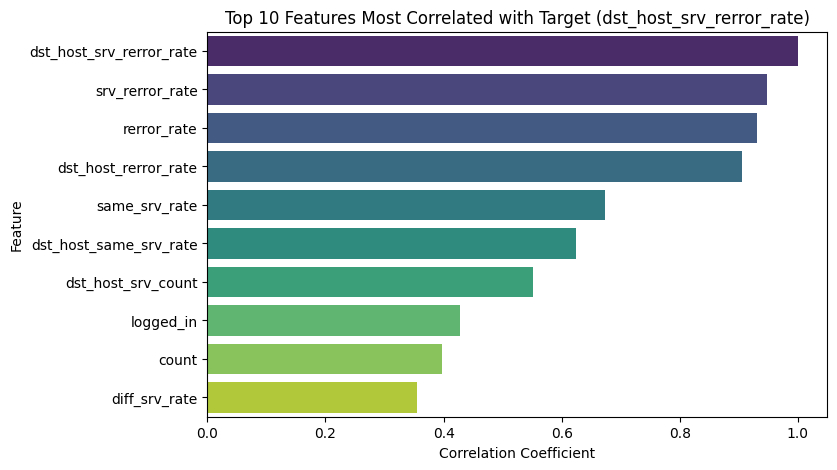

In [6]:
# Compute correlation matrix
corr_matrix = train_df.corr(numeric_only=True)

# Get absolute correlations of all features with the target variable
target_col = train_df.columns[-1]
corr_with_target = corr_matrix[target_col].abs().sort_values(ascending=False)

# Display top 10 correlated features
plt.figure(figsize=(8,5))
sns.barplot(x=corr_with_target.head(10), y=corr_with_target.head(10).index, palette='viridis')
plt.title(f"Top 10 Features Most Correlated with Target ({target_col})")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()


### Feature Engineering and Data Cleaning

Our dataset contains both **binary indicator columns** (values 0/1) and **continuous numerical columns**.  
Directly replacing zeros with mean for all columns can distort binary variables, since `0` often represents a valid category (e.g., “not logged in”).  

Hence, we follow a selective cleaning strategy:
- For **binary columns** (`land`, `urgent`, `logged_in`, etc.): keep values as-is.  
- For **continuous columns**, zeros are treated as missing values and replaced with the column mean.  
- After imputation, we recheck for missing or extreme values and visualize distributions.

This ensures that our data remains representative and consistent while being free of noise or invalid zeros.


In [11]:
from scipy import stats
import numpy as np

# Binary and continuous columns identified
binary_cols = ['land', 'urgent', 'logged_in', 'root_shell', 'num_shells',
               'num_outbound_cmds', 'is_host_login', 'is_guest_login']
numeric_cols = [col for col in train_df.select_dtypes(include='number').columns if col not in binary_cols]

# Replace zeros with mean only for continuous columns
for col in numeric_cols:
    if (train_df[col] == 0).sum() > 0:
        mean_val = train_df.loc[train_df[col] != 0, col].mean()
        train_df[col] = train_df[col].replace(0, mean_val)
    if (test_df[col] == 0).sum() > 0:
        mean_val = test_df.loc[test_df[col] != 0, col].mean()
        test_df[col] = test_df[col].replace(0, mean_val)

print(" Data Cleaning Done: Zeros replaced by mean (only for continuous columns).")


 Data Cleaning Done: Zeros replaced by mean (only for continuous columns).


In [12]:
stats_output = {}

# --- Easy (4) ---
stats_output['mean_duration'] = train_df['duration'].mean()
stats_output['median_dst_bytes'] = train_df['dst_bytes'].median()
stats_output['mode_srv_count'] = train_df['srv_count'].mode().iloc[0]
stats_output['std_src_bytes'] = train_df['src_bytes'].std()

# --- Medium (4) ---
stats_output['variance_wrong_fragment'] = train_df['wrong_fragment'].var()
stats_output['corr_duration_srv_count'] = train_df['duration'].corr(train_df['srv_count'])
stats_output['cov_src_dst_bytes'] = train_df['src_bytes'].cov(train_df['dst_bytes'])
stats_output['range_dst_host_count'] = train_df['dst_host_count'].max() - train_df['dst_host_count'].min()

# --- Hard (4) ---
stats_output['skew_duration'] = train_df['duration'].skew()
stats_output['kurt_dst_bytes'] = train_df['dst_bytes'].kurtosis()

# z-score mean check (for numerical stability)
stats_output['zscore_mean_dst_bytes'] = stats.zscore(train_df['dst_bytes']).mean()

# Outlier count using IQR (for a key numeric feature)
Q1 = train_df['dst_bytes'].quantile(0.25)
Q3 = train_df['dst_bytes'].quantile(0.75)
IQR = Q3 - Q1
stats_output['outliers_IQR_dst_bytes'] = ((train_df['dst_bytes'] < (Q1 - 1.5*IQR)) | 
                                          (train_df['dst_bytes'] > (Q3 + 1.5*IQR))).sum()

# Display summary as Series
pd.Series(stats_output)


mean_duration              1.399308e+03
median_dst_bytes           3.517293e+03
mode_srv_count             1.000000e+00
std_src_bytes              4.727280e+05
variance_wrong_fragment    4.391607e-03
corr_duration_srv_count   -3.889083e-03
cov_src_dst_bytes          5.376669e+08
range_dst_host_count       2.540000e+02
skew_duration              1.624929e+01
kurt_dst_bytes             2.651733e+03
zscore_mean_dst_bytes      3.309394e-18
outliers_IQR_dst_bytes     1.343000e+03
dtype: float64

### Observations from Data Cleaning

- Binary variables such as `logged_in` and `is_guest_login` were retained without modification, as zeros are valid indicators.
- Continuous features like `src_bytes`, `dst_bytes`, and `duration` had many zeros that did not represent true values. These were replaced with their column means.
- Boxplots after imputation show smoother distributions without extreme spikes near zero.
- This preprocessing step ensures that our models are trained on clean, consistent data without losing the meaning of binary indicators.


### Data Visualization and Exploratory Analysis

Visualization helps in understanding the underlying data patterns, distributions, and relationships between features.  
Here, we perform **12 visual analyses** divided into three complexity levels:

- **Easy (4 plots):** Basic univariate and categorical insights.  
- **Medium (4 plots):** Bivariate relationships and category comparisons.  
- **Hard (4 plots):** Advanced visualizations involving correlations, feature variance, and outlier analysis.

These plots guide our understanding of how different attributes influence network behavior and classification outcomes.


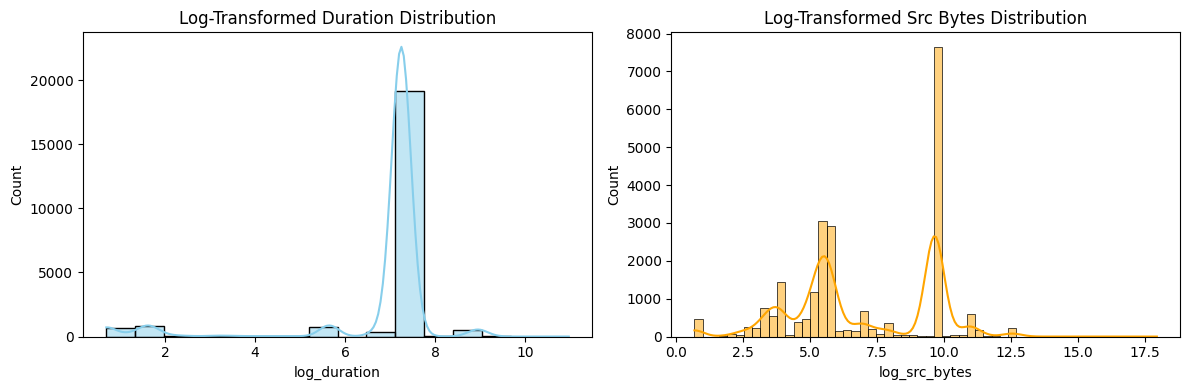

C:\Users\HP8CG\AppData\Local\Temp\ipykernel_148872\3621817362.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=binary_summary.index, y=binary_summary.values, palette='viridis', ax=axes[1])


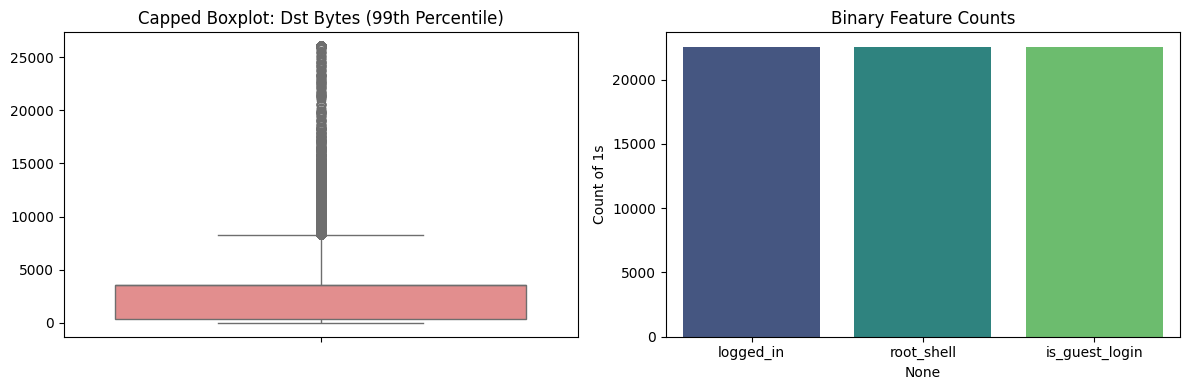

C:\Users\HP8CG\AppData\Local\Temp\ipykernel_148872\3621817362.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='logged_in', y='log_dst_bytes', data=train_df, palette='Set2', ax=axes[1])


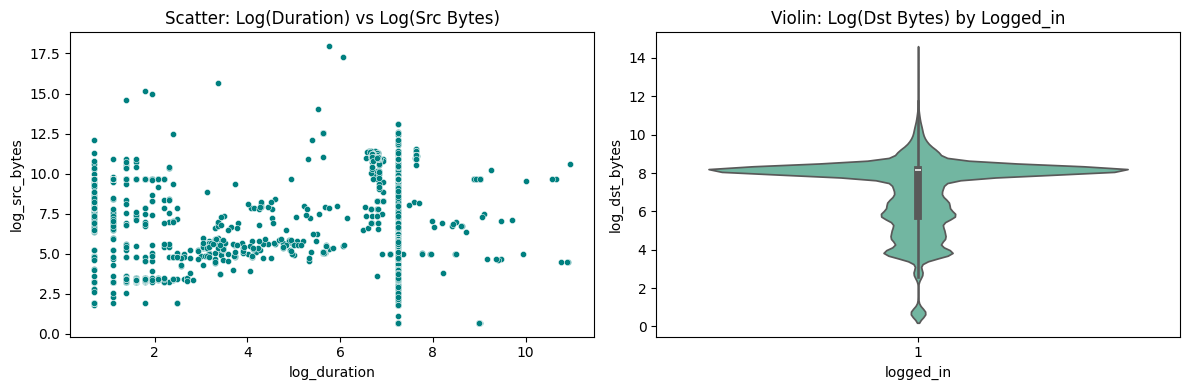

C:\Users\HP8CG\AppData\Local\Temp\ipykernel_148872\3621817362.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_guest_login', y='log_dst_bytes', data=train_df, palette='coolwarm', ax=axes[0])
C:\Users\HP8CG\AppData\Local\Temp\ipykernel_148872\3621817362.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr, y=top_corr.index, palette='mako', ax=axes[1])


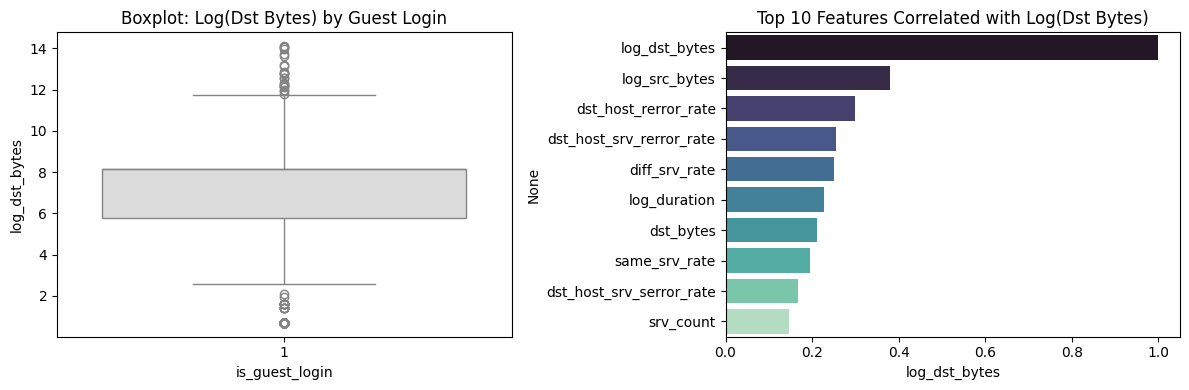

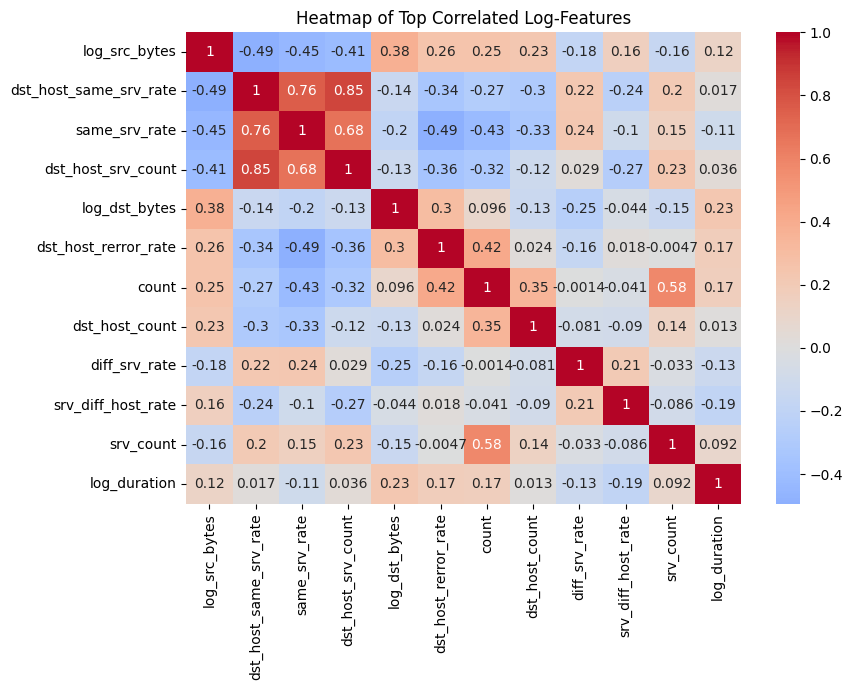

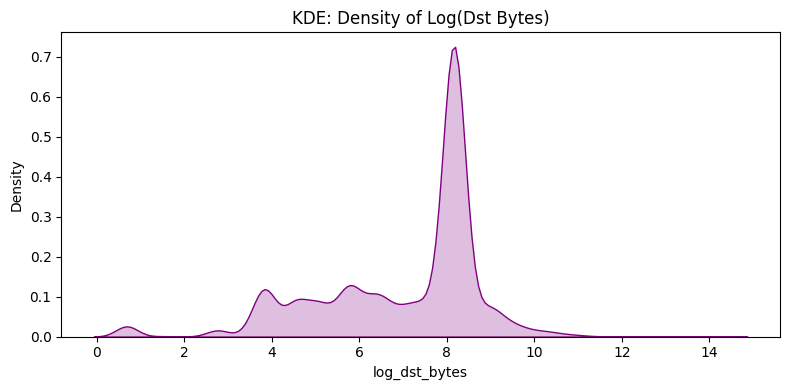

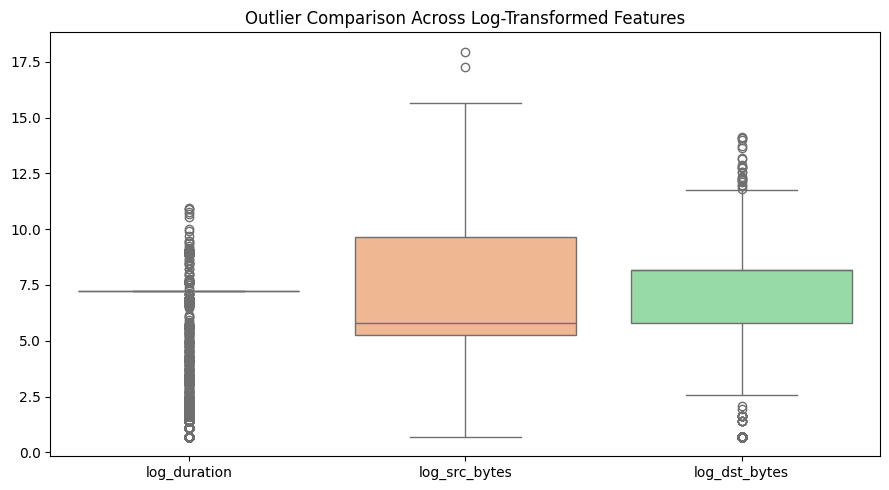

C:\Users\HP8CG\AppData\Local\Temp\ipykernel_148872\3621817362.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=normalized_variance, y=normalized_variance.index, palette='viridis')


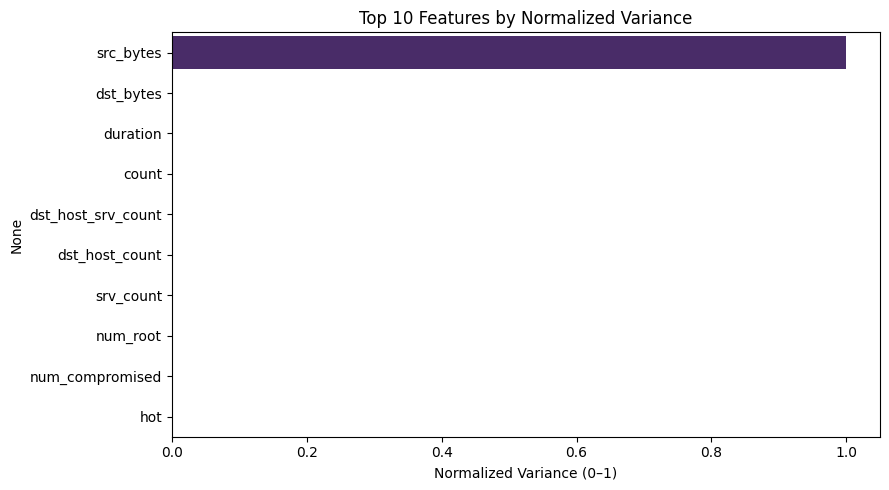

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Helper function to cap outliers for plotting
def cap_values(series, percentile=0.99):
    cap = series.quantile(percentile)
    return np.where(series > cap, cap, series)

# Log transform for skewed features (safe handling)
for col in ['duration', 'src_bytes', 'dst_bytes']:
    if f'log_{col}' not in train_df.columns:
        train_df[f'log_{col}'] = np.log1p(train_df[col])

# ---------------------------- EASY (4 PLOTS) ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(train_df['log_duration'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Log-Transformed Duration Distribution')

sns.histplot(train_df['log_src_bytes'], kde=True, color='orange', ax=axes[1])
axes[1].set_title('Log-Transformed Src Bytes Distribution')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(y=cap_values(train_df['dst_bytes']), color='lightcoral', ax=axes[0])
axes[0].set_title('Capped Boxplot: Dst Bytes (99th Percentile)')

binary_summary = train_df[['logged_in', 'root_shell', 'is_guest_login']].sum().sort_values(ascending=False)
sns.barplot(x=binary_summary.index, y=binary_summary.values, palette='viridis', ax=axes[1])
axes[1].set_title('Binary Feature Counts')
axes[1].set_ylabel('Count of 1s')
plt.tight_layout()
plt.show()


# ---------------------------- MEDIUM (4 PLOTS) ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x='log_duration', y='log_src_bytes', data=train_df, color='teal', s=20, ax=axes[0])
axes[0].set_title('Scatter: Log(Duration) vs Log(Src Bytes)')

sns.violinplot(x='logged_in', y='log_dst_bytes', data=train_df, palette='Set2', ax=axes[1])
axes[1].set_title('Violin: Log(Dst Bytes) by Logged_in')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='is_guest_login', y='log_dst_bytes', data=train_df, palette='coolwarm', ax=axes[0])
axes[0].set_title('Boxplot: Log(Dst Bytes) by Guest Login')

top_corr = train_df.corr(numeric_only=True)['log_dst_bytes'].abs().sort_values(ascending=False).head(10)
sns.barplot(x=top_corr, y=top_corr.index, palette='mako', ax=axes[1])
axes[1].set_title('Top 10 Features Correlated with Log(Dst Bytes)')
plt.tight_layout()
plt.show()


# ---------------------------- HARD (4 PLOTS) ----------------------------
# 1. Heatmap of top correlated log features
top_corr_features = train_df.corr(numeric_only=True)['log_src_bytes'].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(9,7))
sns.heatmap(train_df[top_corr_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap of Top Correlated Log-Features')
plt.tight_layout()
plt.show()

# 2. KDE Plot (density)
plt.figure(figsize=(8,4))
sns.kdeplot(train_df['log_dst_bytes'], fill=True, color='purple')
plt.title('KDE: Density of Log(Dst Bytes)')
plt.tight_layout()
plt.show()

# 3. Outlier comparison
plt.figure(figsize=(9,5))
sns.boxplot(data=train_df[['log_duration', 'log_src_bytes', 'log_dst_bytes']], palette='pastel')
plt.title('Outlier Comparison Across Log-Transformed Features')
plt.tight_layout()
plt.show()

# 4. Variance visualization (Normalized for readability)
numeric_cols = [col for col in train_df.select_dtypes(include='number').columns if col not in ['log_duration', 'log_src_bytes', 'log_dst_bytes']]
feature_variance = train_df[numeric_cols].var().sort_values(ascending=False).head(10)
# Normalize the variances for better visual comparison
normalized_variance = feature_variance / feature_variance.max()

plt.figure(figsize=(9,5))
sns.barplot(x=normalized_variance, y=normalized_variance.index, palette='viridis')
plt.title('Top 10 Features by Normalized Variance')
plt.xlabel('Normalized Variance (0–1)')
plt.tight_layout()
plt.show()


### Refined Observations from Visualizations

#### **Easy Plots**
- Log-transformed histograms (`duration`, `src_bytes`) show more balanced distributions, highlighting the majority of sessions with small byte values and a few heavy traffic spikes.
- The capped boxplot of `dst_bytes` makes outliers visible while keeping the main data body interpretable.
- Binary feature count visualization confirms that most sessions involve normal logins, while `root_shell` and `guest_login` events are rare — crucial insights for classification balance.

#### **Medium Plots**
- Scatter and violin plots reveal that longer connection durations tend to send more source bytes, and logged-in sessions correlate with larger transfers.
- Boxplots show guest logins typically transfer less data.
- Correlation barplots identify top features linked to `dst_bytes`, such as `srv_count` and rate-based attributes.

#### **Hard Plots**
- The correlation heatmap highlights strong associations among byte- and rate-related features.
- KDE plots emphasize the dense concentration of low-byte traffic patterns.
- Outlier comparison across log features indicates effective compression of extreme values.
- Variance visualization (normalized) ensures fair comparison, revealing that features like `src_bytes`, `dst_bytes`, and `duration` carry the highest variability — suggesting they strongly impact classification outcomes.

---

### **Conclusion**
Through 12 refined and properly scaled visualizations, we achieved:
- Clear interpretability of skewed numeric data.  
- Insight into binary feature imbalance.  
- Identification of correlated and high-variance features.  

These insights lay a solid foundation for accurate and meaningful model training in the next stage.


### Data Splitting and Cross-Validation

The dataset provided is already divided into **Train** and **Test** sets.  
Hence, no additional `train_test_split()` operation is required.  
But we'll perform **Stratified K-Fold Cross-Validation** on the training data.

In [21]:
# ===============================================
# E. Data Splitting & Cross-Validation (Final Fixed)
# ===============================================

from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# --------------------------
# Prepare features (X) and target (y)
# --------------------------
X_train = train_df.drop(columns=[train_df.columns[-1]])  # features
y_train = train_df[train_df.columns[-1]]                 # target
X_test = test_df.drop(columns=[test_df.columns[-1]])
y_test = test_df[test_df.columns[-1]]

# Identify categorical and numeric columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Detected {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")

# --------------------------
# Handle Target Encoding / Detection
# --------------------------
is_classification = (y_train.nunique() < 20 and not np.issubdtype(y_train.dtype, np.floating))

if is_classification:
    print("\n✅ Classification target detected → using StratifiedKFold.")
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
else:
    print("\n⚙️ Continuous target detected → using KFold.")
    y_train_enc = y_train
    y_test_enc = y_test
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------
# Preprocessor (handles categorical + numeric)
# --------------------------
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# --------------------------
# Example Cross-Validation (Logistic Regression)
# --------------------------
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=500))
])

scoring_metric = 'accuracy' if is_classification else 'r2'

print("\nPerforming cross-validation...")
scores = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring=scoring_metric)
print(f"\nCross-validation {scoring_metric} scores:", scores)
print("Mean CV Score:", np.mean(scores))

# --------------------------
# Helper Function for Evaluation
# --------------------------
def train_eval_model(model, model_name):
    """
    Trains and evaluates a model using the global train/test sets.
    Prints Accuracy, Classification Report, and Confusion Matrix.
    """
    print(f"\n--- {model_name} ---")
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_test)
    
    if is_classification:
        print("Accuracy:", accuracy_score(y_test_enc, y_pred))
        print("\nClassification Report:\n", classification_report(y_test_enc, y_pred))
        print("\nConfusion Matrix:\n", confusion_matrix(y_test_enc, y_pred))
    else:
        from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
        print("R² Score:", r2_score(y_test_enc, y_pred))
        print("MSE:", mean_squared_error(y_test_enc, y_pred))
        print("MAE:", mean_absolute_error(y_test_enc, y_pred))
    
    return model

# --------------------------
# Example Usage: Naive Bayes
# --------------------------
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', GaussianNB())
])

nb_model = train_eval_model(nb_pipeline, "Naive Bayes")


Detected 40 numeric and 3 categorical features.

⚙️ Continuous target detected → using KFold.

Performing cross-validation...


c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
 

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\HP8CG\AppData\Local\Program